# 17 — Materiality-weighted net score per group

For each group, weight the `(MORE − LESS)` balance by the **materiality
rank** of the resource type: a group's score worsens when many of its
rules concern a high-materiality resource (Bodily Autonomy, Legal
Standing) and moves less on low-materiality resources (Honor, Religious
Standing).

The score uses the **signed-log of the net** — `sign(net) ×
log(|net|+1)`, then × weight — which preserves direction while
compressing magnitude so a handful of high-count cells don't swamp the
total.

Finally we use that score to compute an **inequality factor** per
binary criterion (Citizenship, Gender, Wealth).

`group_meta` is multi-label (up to 3 canonicals joined with `;`); we
explode on `;` so a rule annotated *Men;Elders* contributes to both
buckets.

**Source**: `data/processed_data/rules_final_dataset_130works_april_2026.tsv`.

*Follows `notebook_rule.md`.*

## 1. Setup — imports, style, constants

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

GROUPS = ['Citizens', 'Slaves', 'The wealthy',
          'The poor', 'Men', 'Women']

# Materiality weights: rank 1 = most material → weight 8; rank 8 → weight 1.
MATERIALITY_RANK = {
    'Bodily Autonomy':     1,
    'Legal Standing':      2,
    'Household Authority': 3,
    'Material Wealth':     4,
    'Education':           5,
    'Political Power':     6,
    'Honor':               7,
    'Religious Standing':  8,
}
W = {t: 9 - r for t, r in MATERIALITY_RANK.items()}

In [2]:
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0,
    'xtick.major.size': 3,
    'ytick.major.size': 0,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.frameon': False,
})

POS_COLOR = '#2c6e91'
NEG_COLOR = '#c0392b'

## 2. Load data

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')
df_raw[['rule', 'directionality', 'group_meta', 'resource_type']].head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv


,rule,directionality,group_meta,resource_type
0,Greek exclusion from large-scale statecraft,LESS,Greeks,Political Power
1,City-state local self-government,MORE,Citizens;Greeks,Political Power
2,Noble access to magistracies,MORE,Nobles,Political Power
3,Citizen assembly voting,MORE,Citizens,Political Power
4,Proconsular annulment of local power,LESS,Citizens,Political Power


## 3. Preprocessing

Keep rated rules (MORE / LESS) with a known `resource_type`. Compound
`resource_type` values are collapsed to the **primary** (first-listed)
type. `group_meta` is exploded on `;` so a multi-label rule contributes
to every meta-group it belongs to; then we keep only the six target
groups.

In [4]:
n0 = len(df_raw)

df = df_raw[df_raw['directionality'].isin(['MORE', 'LESS'])
            & df_raw['group_meta'].notna()
            & df_raw['resource_type'].notna()].copy()
n1 = len(df)

df['resource_type_primary'] = df['resource_type'].map(
    lambda s: s.split(';')[0].strip())

# Multi-label group_meta: explode on ';' so a rule like "Men;Elders"
# contributes one unit to each of Men and Elders.
df = (df.assign(group_meta=df['group_meta']
                            .str.split(r'\s*;\s*'))
        .explode('group_meta'))
df['group_meta'] = df['group_meta'].str.strip()
df = df[df['group_meta'] != ''].copy()
n_exploded = len(df)

# Keep all groups here; §4 restricts to the six target groups via .reindex.
# This lets §9 compute scores for any (in-group, out-group) pair.
n_target = df['group_meta'].isin(GROUPS).sum()

print(f'Raw rules:                             {n0:,}')
print(f'After MORE/LESS + group + type filter: {n1:,}  (dropped {n0-n1})')
print(f'After group_meta explode:              {n_exploded:,}  '
      f'(+{n_exploded-n1} rows from multi-label)')
print(f'Rows in 6 target groups:               {n_target:,}')
print(f'Distinct group_meta values available:  {df["group_meta"].nunique()}')
df.head()

Raw rules:                             1,011
After MORE/LESS + group + type filter: 998  (dropped 13)
After group_meta explode:              1,124  (+126 rows from multi-label)
Rows in 6 target groups:               679
Distinct group_meta values available:  37


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type,group_meta,resource_type_primary
0,tlg0007.tlg118.perseus-eng3::0,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Greek ethnicity is a birth-fixed biological/cu...,0,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...,Political Power,Greeks,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Citizens,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Greeks,Political Power
2,tlg0007.tlg118.perseus-eng3::2,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,'Noble birth' is a strictly immutable lineage-...,0,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...,Political Power,Nobles,Political Power
3,tlg0007.tlg118.perseus-eng3::3,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Status as 'Athenian citizens' and 'free men' i...,0,Refers to the current population of Athens rul...,4,"While hortatory, it identifies the group as 'f...",0,Being 'free' or 'Greek' does not automatically...,Political Power,Citizens,Political Power


## 4. Build the count matrices (groups × resource types)

In [5]:
more = (df[df['directionality'] == 'MORE']
        .groupby(['group_meta', 'resource_type_primary']).size()
        .unstack(fill_value=0)
        .reindex(index=GROUPS, columns=list(W), fill_value=0))
less = (df[df['directionality'] == 'LESS']
        .groupby(['group_meta', 'resource_type_primary']).size()
        .unstack(fill_value=0)
        .reindex(index=GROUPS, columns=list(W), fill_value=0))
net = more - less
n_rules = (more + less).sum(axis=1)

print('MORE matrix:'); print(more.to_string()); print()
print('LESS matrix:'); print(less.to_string()); print()
print('Net (MORE − LESS):'); print(net.to_string())

MORE matrix:
resource_type_primary  Bodily Autonomy  Legal Standing  Household Authority  Material Wealth  Education  Political Power  Honor  Religious Standing
group_meta                                                                                                                                         
Citizens                            37              52                    0               15          4               94     11                   2
Slaves                              12               7                    0                7          2                3      0                   0
The wealthy                          6               2                    0                9          1               21      1                   0
The poor                             2               0                    0                5          1               15      0                   1
Men                                  7               3                    0               11       

## 5. Compute the signed-log score

`signed_log(x) = sign(x) × log(|x|+1)` preserves direction and
compresses magnitude. We apply it cell-wise to the net, multiply by the
materiality weight, and sum per group.

In [6]:
signed_log_net = np.sign(net) * np.log1p(net.abs())
score_slog = signed_log_net.multiply(pd.Series(W), axis=1).sum(axis=1)

summary = pd.DataFrame({
    'n_rules': n_rules.astype(int),
    'MORE':    more.sum(axis=1).astype(int),
    'LESS':    less.sum(axis=1).astype(int),
    'score':   score_slog.round(2),
}).reindex(GROUPS)
summary

,n_rules,MORE,LESS,score
group_meta,,,,
Citizens,310,215,95,57.63
Slaves,75,31,44,-5.87
The wealthy,105,40,65,4.96
The poor,54,24,30,-8.60
Men,53,36,17,24.99
Women,82,39,43,-21.53


## 6. Plotting helper

Horizontal diverging bar with arrow annotations for the score panel.

In [7]:
def diverging_score_bar(ranked, xlabel, fmt='{:+.1f}', *,
                        xlim=None):
    fig, ax = plt.subplots(figsize=(9, max(4, 0.55 * len(ranked))))
    y = np.arange(len(ranked))
    colors = [POS_COLOR if v > 0 else NEG_COLOR for v in ranked.values]
    ax.barh(y, ranked.values, color=colors, edgecolor='none', height=0.72)
    ax.axvline(0, color='#1d1d1f', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f'{g}  (n={int(n_rules[g])})'
                        for g in ranked.index],
                       fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)

    mv = xlim if xlim is not None else max(abs(ranked.min()),
                                           abs(ranked.max()))
    ax.set_xlim(-mv * 1.2, mv * 1.2)

    for yi, v in zip(y, ranked.values):
        offset = mv * 0.015 if v >= 0 else -mv * 0.015
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + offset, yi, fmt.format(v),
                ha=ha, va='center', fontsize=10, color='#333')

    y_arrow = len(ranked) - 0.1 + 0.8
    arrow_len = mv * 0.5
    ax.annotate('', xy=(-arrow_len, y_arrow), xytext=(-mv*0.02, y_arrow),
                arrowprops=dict(arrowstyle='-|>', lw=1.3, color=NEG_COLOR,
                                shrinkA=0, shrinkB=0, mutation_scale=14),
                annotation_clip=False)
    ax.annotate('', xy=(arrow_len, y_arrow), xytext=(mv*0.02, y_arrow),
                arrowprops=dict(arrowstyle='-|>', lw=1.3, color=POS_COLOR,
                                shrinkA=0, shrinkB=0, mutation_scale=14),
                annotation_clip=False)
    ax.text(-arrow_len, y_arrow + 0.35, 'more materially restricted',
            ha='center', va='top', fontsize=10, fontweight='bold',
            color=NEG_COLOR, clip_on=False)
    ax.text(arrow_len, y_arrow + 0.35, 'more materially privileged',
            ha='center', va='top', fontsize=10, fontweight='bold',
            color=POS_COLOR, clip_on=False)
    ax.set_ylim(y_arrow + 1.0, -0.5)
    fig.tight_layout()
    return fig, ax

## 7. Figures

### Figure 1: Signed-log of net × weight

`score(g) = Σ sign(net) × log(|net| + 1) × weight`. Preserves sign,
compresses magnitude — a net of ±40 becomes ≈ ±3.7; a net of ±1 becomes
≈ ±0.69.

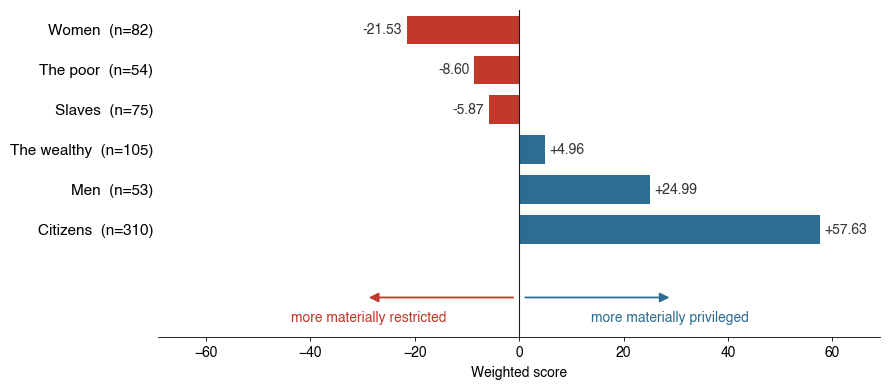

In [8]:
diverging_score_bar(score_slog.sort_values(),
                    xlabel='Weighted score',
                    fmt='{:+.2f}');

## 10. Evidence-level-weighted score

Each work in the corpus carries a source-type label in the
`work_factuality` column of
`data/clean/final/final_dataset_for_criteria.tsv` (written by notebook
11 via `scripts/classify_source_type.py`). The label captures the kind
of evidence the work provides about a rule existing in the author's
own society:

| code | weight | description |
|---|---|---|
| A_legal_constitutional  | **5** | Statute / constitutional clause quoted verbatim (Aristotle's *Ath. Pol.*) |
| B_oration               | **4** | Court speech / political oration invoking an extant law (10 Attic orators) |
| C_historical            | **3** | Historical / biographical work (Plutarch Lives, Thucydides, Polybius, Pausanias, Diogenes Laertius, …) |
| D_contemporary_treatise | **2** | Philosophical / political treatise implying the rule exists (Plato, Aristotle, Xenophon treatises, Moralia, Epictetus) |
| E_entertainment         | **1** | Drama / satire / fiction (Aristophanes, Lucian satire, Plutarch *Sayings*) |

We re-do the signed-log × materiality score, giving each rule a weight
equal to the **evidence level of the work it was extracted from**. A
rule from Aristotle's *Ath. Pol.* counts 5×; a rule from Aristophanes
counts 1×.

- Rules whose `file_id` is not in `final_dataset_for_criteria.tsv` are
  dropped (the 328-work corpus of notebook 11 excludes historians
  covering non-Greek polities, etc.).
- `F_religious_scriptural` rules are also dropped, mirroring notebook
  11.

Pipeline:

1. Merge `work_factuality` onto the rule set on `file_id`.
2. Drop missing + F; map A=5 … E=1.
3. Per `(group, resource_type)` cell, **sum the rule weights** for MORE
   and LESS separately.
4. Net = MORE-weight − LESS-weight; signed-log × materiality weight as
   before; sum per group.

Figure 5 plots the evidence-level-weighted score alongside the
unweighted one from §7 so the shift is visible.

In [9]:
ANNOT = Path('../data/clean/final/final_dataset_for_criteria.tsv')

EVIDENCE_WEIGHT = {
    'A_legal_constitutional':  5,
    'B_oration':               4,
    'C_historical':            3,
    'D_contemporary_treatise': 2,
    'E_entertainment':         1,
}

annot = pd.read_csv(ANNOT, sep='\t', usecols=['file_id', 'work_factuality'])
print(f'Loaded work_factuality for {len(annot):,} works from {ANNOT.name}')

annot

Loaded work_factuality for 328 works from final_dataset_for_criteria.tsv


,file_id,work_factuality
0,tlg0027.tlg004.perseus-eng2,B_oration
1,tlg0027.tlg002.perseus-eng2,B_oration
2,tlg0027.tlg001.perseus-eng2,B_oration
3,tlg0027.tlg003.perseus-eng2,B_oration
4,tlg0028.tlg006.perseus-eng2,B_oration
...,...,...
323,tlg0535.tlg001.perseus-eng2,B_oration
324,tlg0029.tlg005.perseus-eng2,B_oration
325,tlg0029.tlg004.perseus-eng2,B_oration
326,tlg0029.tlg006.perseus-eng2,B_oration


In [10]:
df_ev = df.merge(annot, on='file_id', how='left')
n_total  = len(df_ev)
n_no_wf  = df_ev['work_factuality'].isna().sum()
n_f      = (df_ev['work_factuality'] == 'F_religious_scriptural').sum()
df_ev = df_ev[df_ev['work_factuality'].isin(EVIDENCE_WEIGHT)].copy()
df_ev['rule_weight'] = df_ev['work_factuality'].map(EVIDENCE_WEIGHT).astype(float)
df_ev

,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type,group_meta,resource_type_primary,work_factuality,rule_weight
8,tlg0014.tlg059.perseus-eng2::0,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,Demosthenes is speaking about a contemporary l...,5,Verbatim describes a legal procedure as pure a...,0,Being a citizen does not define the specific p...,Political Power,Citizens,Political Power,B_oration,4.0
9,tlg0014.tlg059.perseus-eng2::1,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,Demosthenes refers to current Athenian laws on...,5,States 'the laws prescribed' the fund allocati...,0,Being wealthy does not define the legislative ...,Material Wealth,The wealthy,Material Wealth,B_oration,4.0
10,tlg0014.tlg059.perseus-eng2::2,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,Describes the active legal situation of the sp...,5,"States the legal consequences of debt (atimia,...",0,Debt does not conceptually mean 'loss of right...,Legal Standing; Political Power,The poor,Legal Standing,B_oration,4.0
11,tlg0014.tlg059.perseus-eng2::3,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,Directly quotes an Athenian statute in force a...,5,Verbatim is a pure citation of a statute.,0,Being an alien does not define the specific pe...,Legal Standing; Household Authority,Foreigners,Legal Standing,B_oration,4.0
12,tlg0014.tlg059.perseus-eng2::5,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,Describes the practical legal constraints on t...,5,Discusses the legal necessity of a patron as a...,0,Alien status does not conceptually necessitate...,Legal Standing; Political Power,Foreigners,Legal Standing,B_oration,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,tlg0540.tlg029.perseus-eng2::2,tlg0540.tlg029.perseus-eng2,Lysias,Against Philocrates,Q87778222,Against Philocrates,Q310164,-409,-409,Classical (500–360 BCE),...,Describes current Athenian legal penalties for...,5,Describes the legal reality and its consequenc...,0,Being wealthy does not define one as having an...,Material Wealth,The wealthy,Material Wealth,B_oration,4.0
1103,tlg0540.tlg030.perseus-eng2::0,tlg0540.tlg030.perseus-eng2,Lysias,Against Nicomachus,Q87740748,Against Nicomachus,Q310164,-409,-409,Classical (500–360 BCE),...,The audit was a standard contemporary Athenian...,5,The verbatim states the rule applies to 'every...,0,Holding a magistracy does not definitionally i...,Legal Standing,Magistrates,Legal Standing,B_oration,4.0
1104,tlg0540.tlg030.perseus-eng2::4,tlg0540.tlg030.perseus-eng2,Lysias,Against Nicomachus,Q87740748,Against Nicomachus,Q310164,-409,-409,Classical (500–360 BCE),...,The author cites the legal consequence for sta...,5,States the legal consequence for servile birth...,0,Being of servile birth does not automatically ...,Bodily Autonomy,Minors,Bodily Autonomy,B_oration,4.0
1105,tlg0540.tlg030.perseus-eng2::4,tlg0540.tlg030.perseus-eng2,Lysias,Against Nicomachus,Q87740748,Against Nicomachus,Q310164,-409,-409,Classical (500–360 BCE),...,The author cites the legal consequence for sta...,5,States the legal consequence for servile birth...,0,Being of servile birth does not automatically ...,Bodily Autonomy,Slaves,Bodily Autonomy,B_oration,4.0


In [11]:


print(f'Rules before merge:                        {n_total:,}')
print(f'Dropped — file_id not in annotation file:  {n_no_wf:,}')
print(f'Dropped — F_religious_scriptural:          {n_f:,}')
print(f'Rules retained:                            {len(df_ev):,}')
print()
print('Rule rows by work_factuality (A=5 … E=1):')
print(df_ev['work_factuality'].value_counts()
                              .reindex(EVIDENCE_WEIGHT).to_string())


def weighted_matrix(sub, direction):
    """Sum `rule_weight` per (group, resource_type) cell."""
    return (sub[sub['directionality'] == direction]
            .groupby(['group_meta', 'resource_type_primary'])['rule_weight']
            .sum()
            .unstack(fill_value=0)
            .reindex(index=GROUPS, columns=list(W), fill_value=0))


def count_matrix(sub, direction):
    """Count rule rows per (group, resource_type) cell (unweighted)."""
    return (sub[sub['directionality'] == direction]
            .groupby(['group_meta', 'resource_type_primary']).size()
            .unstack(fill_value=0)
            .reindex(index=GROUPS, columns=list(W), fill_value=0))


def score_from_matrices(more_m, less_m):
    net_m = more_m - less_m
    slog_m = np.sign(net_m) * np.log1p(net_m.abs())
    return slog_m.multiply(pd.Series(W), axis=1).sum(axis=1)


# (a) Evidence-level-weighted. Each rule contributes its source-work
#     weight (A=5 … E=1) into the (group, resource_type) cell; net =
#     weighted MORE − weighted LESS; signed-log × materiality weight.
score_slog_ev = score_from_matrices(
    weighted_matrix(df_ev, 'MORE'),
    weighted_matrix(df_ev, 'LESS'),
)

# (b) Author-convergence only (no evidence weighting). Work from the
#     base rule set `df`; keep only triples
#     (directionality, resource_type, group_meta) attested by ≥ 2
#     distinct `perseus_author` values; signed-log × materiality weight
#     on plain counts.
triple_cols = ['directionality', 'resource_type_primary', 'group_meta']
n_auth = (df.groupby(triple_cols)['perseus_author']
            .nunique().rename('n_authors'))
shared_triples = n_auth[n_auth >= 2].index
df_shared = (df.set_index(triple_cols)
               .loc[shared_triples]
               .reset_index())
score_slog_shared = score_from_matrices(
    count_matrix(df_shared, 'MORE'),
    count_matrix(df_shared, 'LESS'),
)

n_by_authors = n_auth.value_counts().sort_index().to_dict()
print('\nShared-triple filter (applied to base df, no evidence weighting)')
print('  triple = (directionality, resource_type, group_meta)')
print(f'  Distinct triples total:      {len(n_auth):,}')
print(f'  Triples with 1 author only:  {int((n_auth == 1).sum()):,}  (dropped)')
print(f'  Triples with ≥2 authors:     {len(shared_triples):,}  (kept)')
print(f'  Author-count distribution:   {n_by_authors}')
print(f'  Rule rows retained:          {len(df_shared):,} / {len(df):,}')

summary_ev = pd.DataFrame({
    'score_unweighted':          score_slog.round(2),
    'score_evidence':            score_slog_ev.round(2),
    'score_author_convergence':  score_slog_shared.round(2),
}).reindex(GROUPS).sort_values('score_author_convergence')
summary_ev

Rules before merge:                        1,124
Dropped — file_id not in annotation file:  281
Dropped — F_religious_scriptural:          17
Rules retained:                            826

Rule rows by work_factuality (A=5 … E=1):
work_factuality
A_legal_constitutional      83
B_oration                  339
C_historical                 8
D_contemporary_treatise    285
E_entertainment            111

Shared-triple filter (applied to base df, no evidence weighting)
  triple = (directionality, resource_type, group_meta)
  Distinct triples total:      231
  Triples with 1 author only:  118  (dropped)
  Triples with ≥2 authors:     113  (kept)
  Author-count distribution:   {1: 118, 2: 38, 3: 20, 4: 16, 5: 10, 6: 8, 7: 7, 8: 3, 9: 2, 10: 4, 11: 2, 13: 1, 14: 2}
  Rule rows retained:          968 / 1,124


,score_unweighted,score_evidence,score_author_convergence
group_meta,,,
Women,-21.53,19.93,-24.65
Slaves,-5.87,-14.18,-2.62
The wealthy,4.96,-3.28,4.88
The poor,-8.60,-24.03,11.33
Men,24.99,23.84,25.42
Citizens,57.63,69.28,57.63


### Figures 5a & 5b: evidence-weighted and author-convergence scores

Two separate panels, each comparing one weighting scheme against the
unweighted baseline from §7:

- **Fig 5a** — baseline vs *evidence-level weighted* (A=5 … E=1 per
  source work).
- **Fig 5b** — baseline vs *author-convergence only*: signed-log ×
  materiality on plain counts, but restricted to
  `(directionality, resource_type, group_meta)` triples observed in at
  least 2 distinct authors. No evidence weighting.

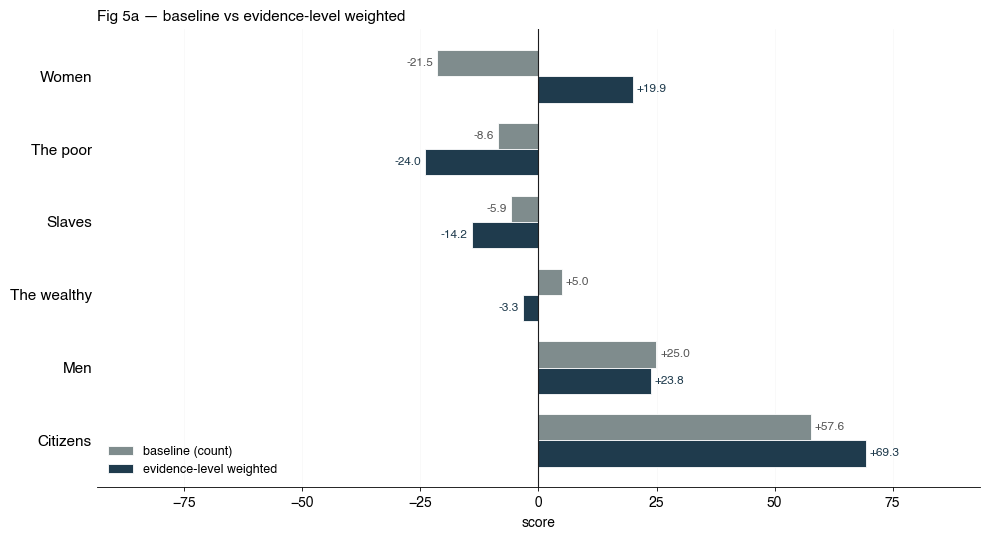

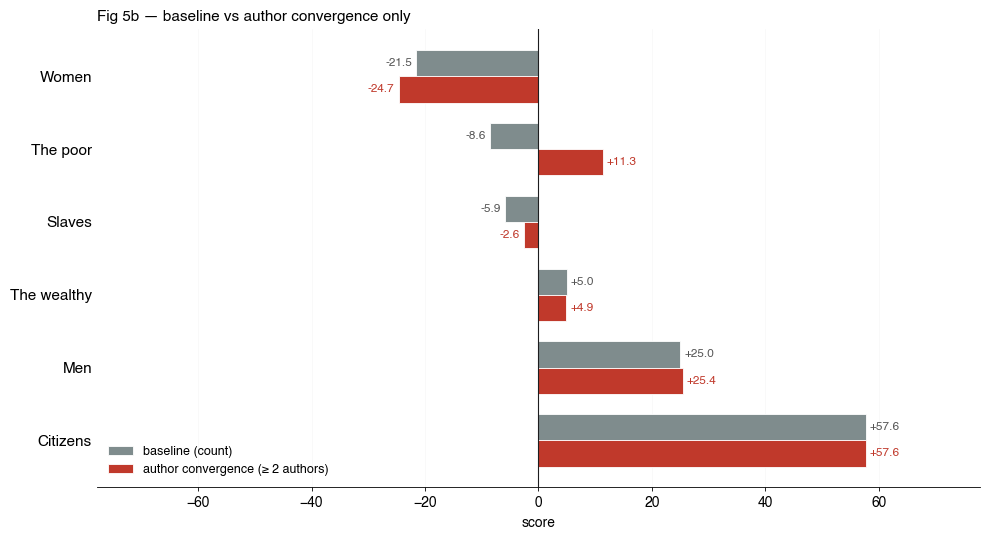

In [12]:
def paired_score_bar(baseline, other, other_label, other_color, *,
                     title):
    ordered = baseline.reindex(GROUPS).sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.75 * len(ordered) + 1)))
    y = np.arange(len(ordered))
    width = 0.36

    b = np.array([baseline[g] for g in ordered])
    o = np.array([other[g]    for g in ordered])

    ax.barh(y - width / 2, b, width,
            color='#7f8c8d', edgecolor='white', linewidth=0.6,
            label='baseline (count)')
    ax.barh(y + width / 2, o, width,
            color=other_color, edgecolor='white', linewidth=0.6,
            label=other_label)

    ax.axvline(0, color='#1d1d1f', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('score')
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(axis='x', alpha=0.12, linewidth=0.4)
    ax.set_axisbelow(True)

    mv = max(abs(np.concatenate([b, o])).max(), 1.0)
    ax.set_xlim(-mv * 1.35, mv * 1.35)

    for yi, (bv, ov) in enumerate(zip(b, o)):
        for v, yy, color in [(bv, yi - width / 2, '#555'),
                             (ov, yi + width / 2, other_color)]:
            offset = mv * 0.012 if v >= 0 else -mv * 0.012
            ha = 'left' if v >= 0 else 'right'
            ax.text(v + offset, yy, f'{v:+.1f}',
                    ha=ha, va='center', fontsize=8.5, color=color)

    fig.tight_layout()
    return fig, ax


paired_score_bar(score_slog, score_slog_ev,
                 other_label='evidence-level weighted',
                 other_color='#1f3b4d',
                 title='Fig 5a — baseline vs evidence-level weighted')
plt.show()

paired_score_bar(score_slog, score_slog_shared,
                 other_label='author convergence (≥ 2 authors)',
                 other_color='#c0392b',
                 title='Fig 5b — baseline vs author convergence only')
plt.show()